In [186]:
import pandas as pd
df = pd.read_csv("Indian_Kids_Screen_Time.csv")
print(df.head())
print(df.info())
print(df.isnull().sum())

   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             TV   
3   15  Female                      1.21         Laptop   
4   12  Female                      5.89     Smartphone   

   Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                               0.49   

           Health_Impacts Urban_or_Rural  
0  Poor Sleep, Eye Strain          Urban  
1              Poor Sleep          Urban  
2              Poor Sleep          Urban  
3                     NaN          Urban  
4     Poor Sleep, Anx

In [187]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Avg_Daily_Screen_Time_hr'] = df['Avg_Daily_Screen_Time_hr'].fillna(df['Avg_Daily_Screen_Time_hr'].mean())
df['Educational_to_Recreational_Ratio'] = df['Educational_to_Recreational_Ratio'].fillna(df['Educational_to_Recreational_Ratio'].mean())

for col in ['Gender', 'Primary_Device', 'Exceeded_Recommended_Limit', 'Health_Impacts', 'Urban_or_Rural']:
    df[col] = df[col].fillna(df[col].mode()[0])

In [188]:
df['Gender'] = df['Gender'].astype('category')
df['Primary_Device'] = df['Primary_Device'].astype('category')
df['Exceeded_Recommended_Limit'] = df['Exceeded_Recommended_Limit'].astype('category')
df['Health_Impacts'] = df['Health_Impacts'].astype('category')
df['Urban_or_Rural'] = df['Urban_or_Rural'].astype('category')

In [189]:
print(df.columns)

Index(['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device',
       'Exceeded_Recommended_Limit', 'Educational_to_Recreational_Ratio',
       'Health_Impacts', 'Urban_or_Rural'],
      dtype='object')


In [190]:
df=df.drop_duplicates()

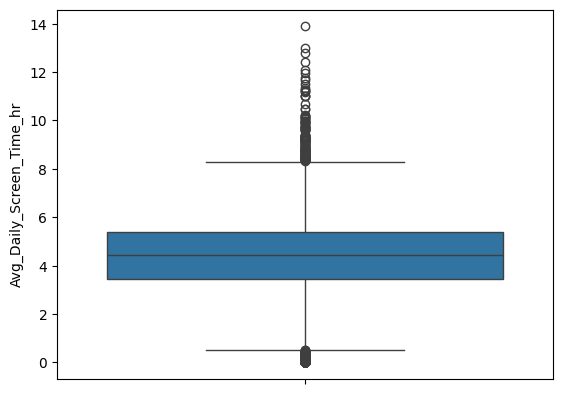

In [191]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(df['Avg_Daily_Screen_Time_hr'])
plt.show()

Q1 = df['Avg_Daily_Screen_Time_hr'].quantile(0.25)
Q3 = df['Avg_Daily_Screen_Time_hr'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Avg_Daily_Screen_Time_hr'] >= Q1 - 1.5 * IQR) & (df['Avg_Daily_Screen_Time_hr'] <= Q3 + 1.5 * IQR)]

In [192]:
bins = [0, 12, 18, 25, 40, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Middle Age', 'Senior']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [193]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [194]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 9235 entries, 0 to 9711
Data columns (total 9 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   Age                                9235 non-null   int64   
 1   Gender                             9235 non-null   category
 2   Avg_Daily_Screen_Time_hr           9235 non-null   float64 
 3   Primary_Device                     9235 non-null   category
 4   Exceeded_Recommended_Limit         9235 non-null   category
 5   Educational_to_Recreational_Ratio  9235 non-null   float64 
 6   Health_Impacts                     9235 non-null   category
 7   Urban_or_Rural                     9235 non-null   category
 8   Age_Group                          9235 non-null   category
dtypes: category(6), float64(2), int64(1)
memory usage: 344.1 KB
None


In [195]:
print(df.head())

   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             TV   
3   15  Female                      1.21         Laptop   
4   12  Female                      5.89     Smartphone   

  Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                       True                               0.42   
1                       True                               0.30   
2                       True                               0.32   
3                      False                               0.39   
4                       True                               0.49   

           Health_Impacts Urban_or_Rural Age_Group  
0  Poor Sleep, Eye Strain          Urban      Teen  
1              Poor Sleep          Urban     Child  
2              Poor Sleep          Urban      Teen  
3              Poor Sleep     

In [196]:
df.dtypes

,0
Age,int64
Gender,category
Avg_Daily_Screen_Time_hr,float64
Primary_Device,category
Exceeded_Recommended_Limit,category
Educational_to_Recreational_Ratio,float64
Health_Impacts,category
Urban_or_Rural,category
Age_Group,category


In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9235 entries, 0 to 9711
Data columns (total 9 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   Age                                9235 non-null   int64   
 1   Gender                             9235 non-null   category
 2   Avg_Daily_Screen_Time_hr           9235 non-null   float64 
 3   Primary_Device                     9235 non-null   category
 4   Exceeded_Recommended_Limit         9235 non-null   category
 5   Educational_to_Recreational_Ratio  9235 non-null   float64 
 6   Health_Impacts                     9235 non-null   category
 7   Urban_or_Rural                     9235 non-null   category
 8   Age_Group                          9235 non-null   category
dtypes: category(6), float64(2), int64(1)
memory usage: 344.1 KB


In [198]:
df.describe()

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9235.000000,9235.000000,9235.00000
mean,13.171413,4.430815,0.42383
std,3.107169,1.431855,0.07207
min,8.000000,0.510000,0.30000
25%,11.000000,3.530000,0.37000
50%,13.000000,4.470000,0.42000
75%,16.000000,5.370000,0.47000
max,18.000000,8.300000,0.60000


In [199]:
df.isnull().sum()

,0
Age,0
Gender,0
Avg_Daily_Screen_Time_hr,0
Primary_Device,0
Exceeded_Recommended_Limit,0
Educational_to_Recreational_Ratio,0
Health_Impacts,0
Urban_or_Rural,0
Age_Group,0


In [200]:
df.duplicated().sum()

np.int64(0)

In [201]:
df.drop_duplicates()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Group
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Teen
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Child
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Teen
3,15,Female,1.21,Laptop,False,0.39,Poor Sleep,Urban,Teen
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Child
...,...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban,Teen
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural,Teen
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural,Teen
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban,Teen


In [202]:
df.shape

(9235, 9)

In [203]:
df["Primary_Device"].unique()

['Smartphone', 'Laptop', 'TV', 'Tablet']
Categories (4, object): ['Laptop', 'Smartphone', 'TV', 'Tablet']

In [204]:
df[df["Age"] > 12]

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Group
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Teen
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Teen
3,15,Female,1.21,Laptop,False,0.39,Poor Sleep,Urban,Teen
5,14,Female,4.88,Smartphone,True,0.44,Poor Sleep,Urban,Teen
6,17,Male,2.97,TV,False,0.48,Poor Sleep,Rural,Teen
...,...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban,Teen
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural,Teen
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural,Teen
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban,Teen


In [205]:
df[df["Primary_Device"] == "Smartphone"]

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Group
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Teen
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Child
5,14,Female,4.88,Smartphone,True,0.44,Poor Sleep,Urban,Teen
12,12,Male,4.59,Smartphone,True,0.43,Poor Sleep,Urban,Child
14,15,Male,6.15,Smartphone,True,0.40,Poor Sleep,Urban,Teen
...,...,...,...,...,...,...,...,...,...
9703,9,Male,6.62,Smartphone,True,0.48,Poor Sleep,Rural,Child
9706,8,Male,4.84,Smartphone,True,0.55,Poor Sleep,Rural,Child
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban,Teen
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural,Teen


In [206]:
df.sort_values("Age",ascending=False)

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Group
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Teen
9,18,Male,3.24,Tablet,True,0.48,"Poor Sleep, Obesity Risk",Urban,Teen
9693,18,Female,7.54,Smartphone,True,0.36,Poor Sleep,Urban,Teen
9683,18,Male,5.11,Smartphone,True,0.39,Obesity Risk,Rural,Teen
10,18,Male,3.53,Tablet,True,0.44,Poor Sleep,Rural,Teen
...,...,...,...,...,...,...,...,...,...
9667,8,Female,0.89,Tablet,False,0.52,Poor Sleep,Urban,Child
9656,8,Female,0.73,TV,False,0.47,Poor Sleep,Urban,Child
1946,8,Male,5.05,TV,True,0.54,Obesity Risk,Rural,Child
8089,8,Female,0.51,Smartphone,False,0.58,Poor Sleep,Rural,Child


In [207]:
import matplotlib.pyplot as plt
import pandas as pd

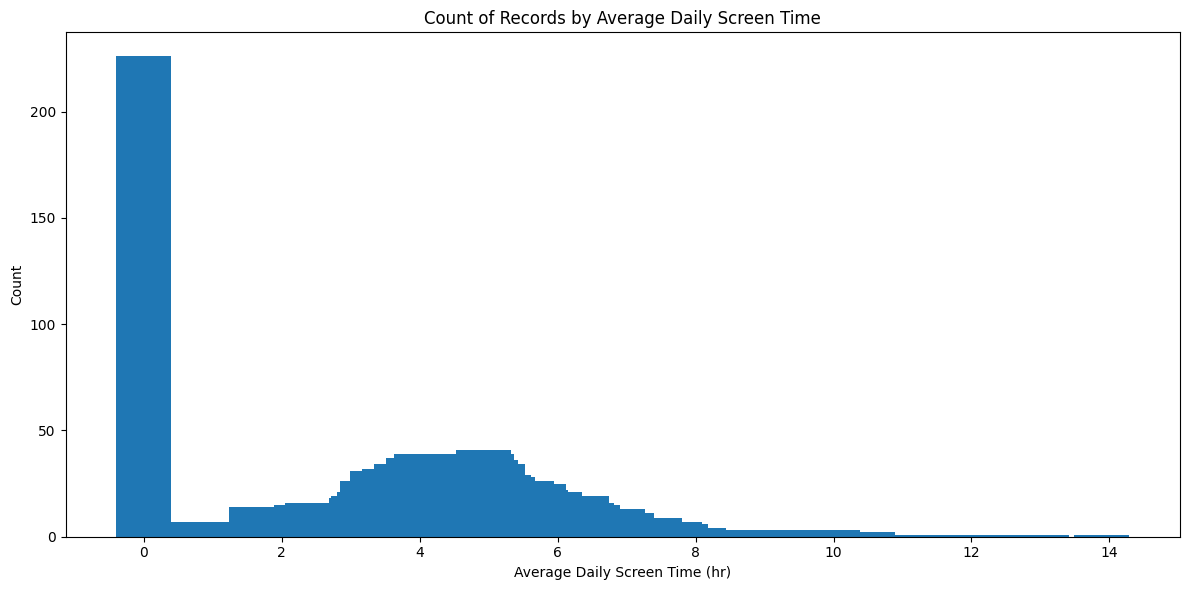

In [208]:
df = pd.read_csv("/content/Indian_Kids_Screen_Time.csv")

screen_time_counts = df['Avg_Daily_Screen_Time_hr'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(screen_time_counts.index, screen_time_counts.values)

plt.xlabel("Average Daily Screen Time (hr)")
plt.ylabel("Count")
plt.title("Count of Records by Average Daily Screen Time")

plt.tight_layout()
plt.show()


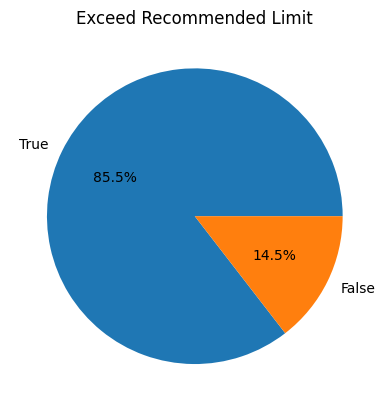

In [209]:
plt.pie(df['Exceeded_Recommended_Limit'].value_counts(), labels=df['Exceeded_Recommended_Limit'].unique(), autopct='%1.1f%%')
plt.title('Exceed Recommended Limit')
plt.show()

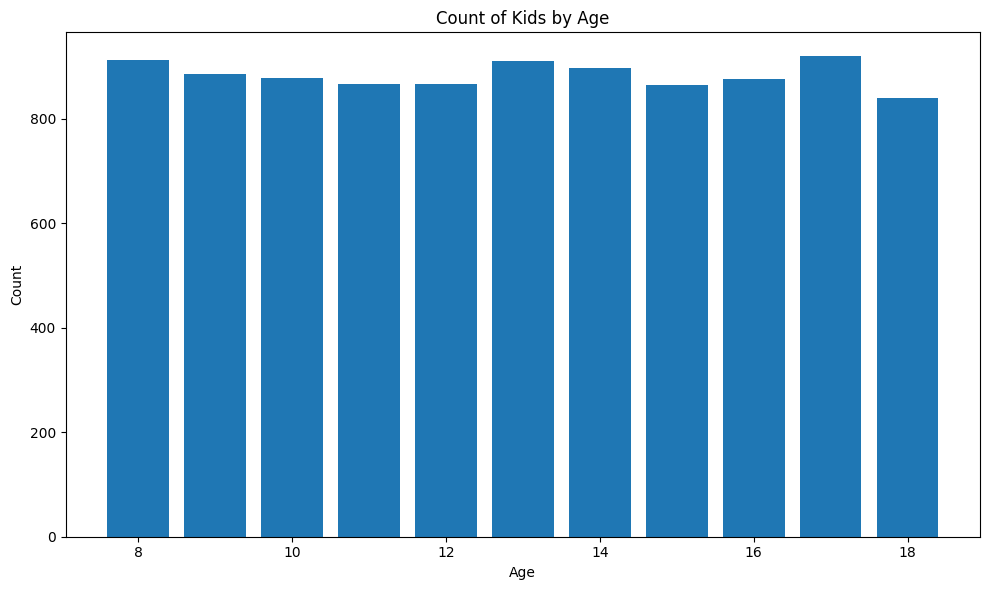

In [211]:
age_counts = df['Age'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(age_counts.index, age_counts.values)

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Count of Kids by Age")

plt.tight_layout()
plt.show()


<Axes: xlabel='Gender', ylabel='Avg_Daily_Screen_Time_hr'>

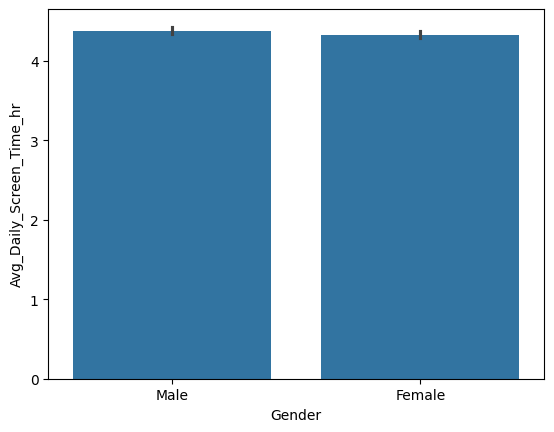

In [212]:
sns.barplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df)

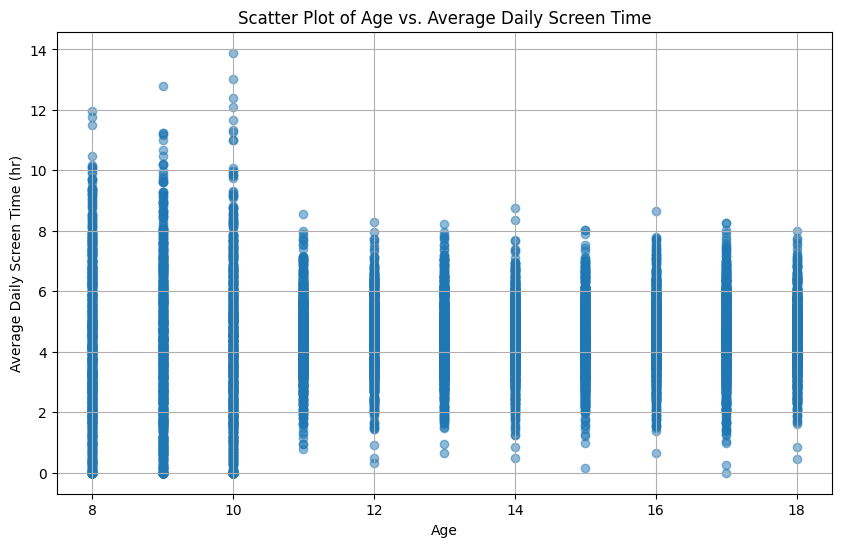

In [213]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Age'], df['Avg_Daily_Screen_Time_hr'], alpha=0.5)

plt.xlabel("Age")
plt.ylabel("Average Daily Screen Time (hr)")
plt.title("Scatter Plot of Age vs. Average Daily Screen Time")

plt.grid(True)
plt.show()


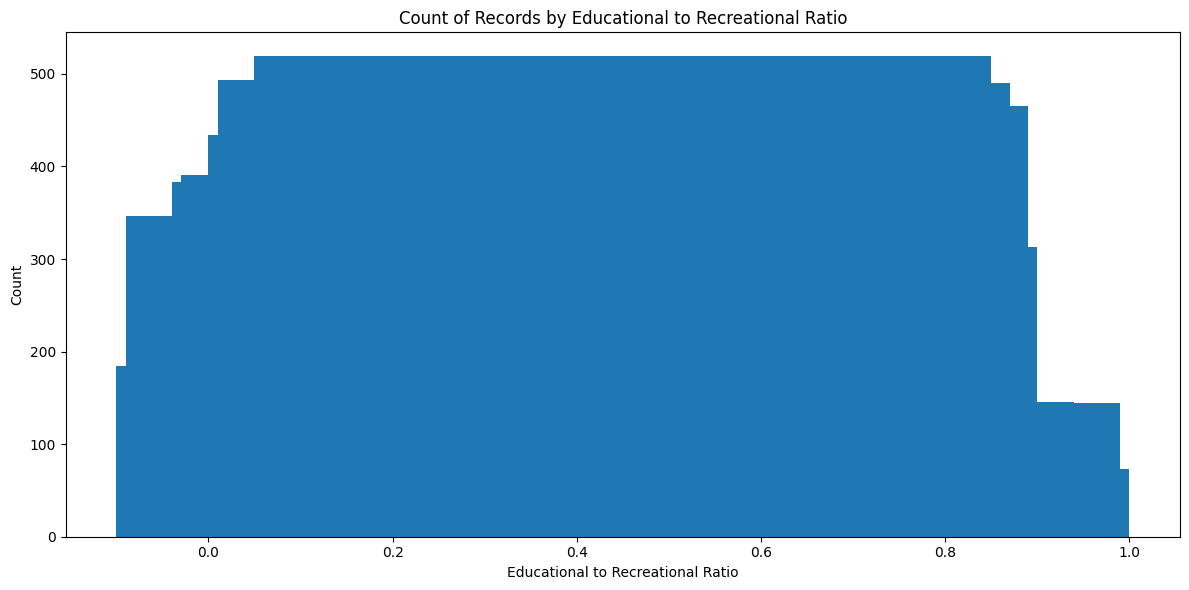

In [214]:
ratio_counts = df['Educational_to_Recreational_Ratio'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(ratio_counts.index, ratio_counts.values)

plt.xlabel("Educational to Recreational Ratio")
plt.ylabel("Count")
plt.title("Count of Records by Educational to Recreational Ratio")

plt.tight_layout()
plt.show()

<Axes: xlabel='Health_Impacts', ylabel='count'>

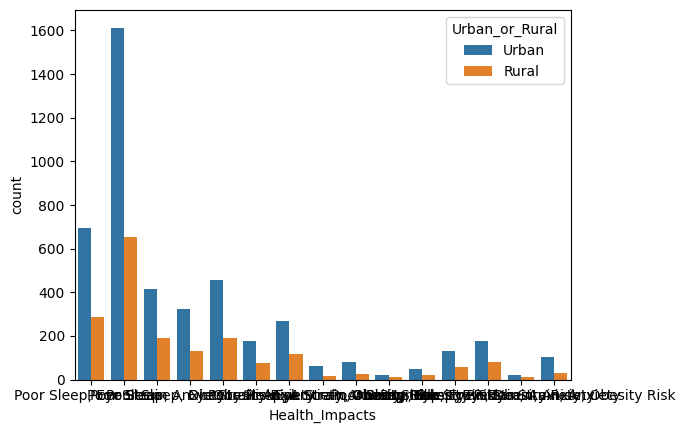

In [215]:
sns.countplot(x='Health_Impacts', hue='Urban_or_Rural', data=df)

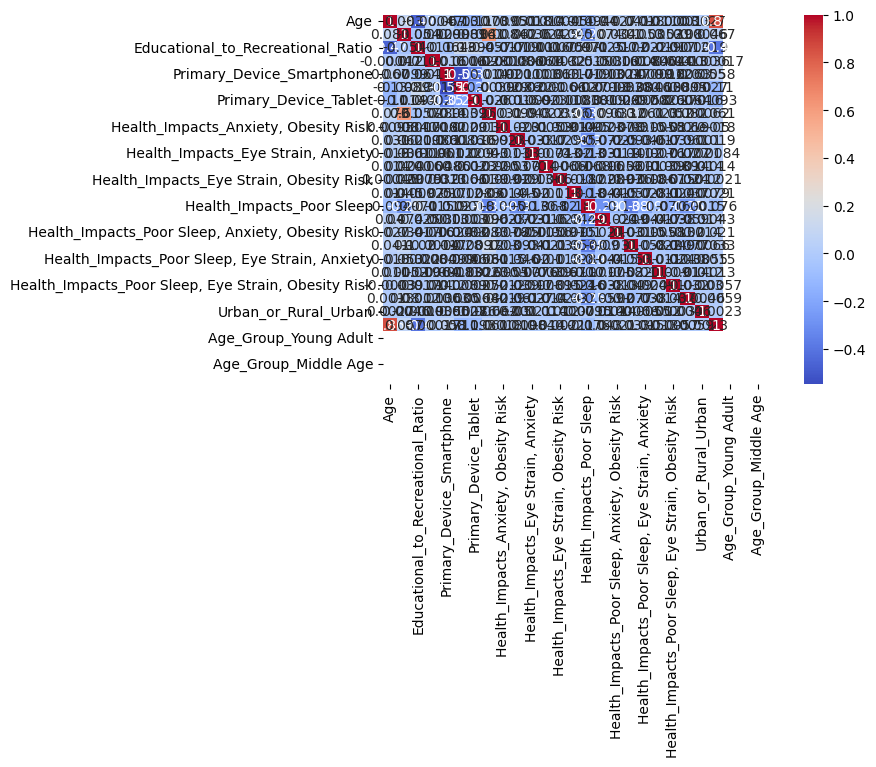

In [216]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.show()

# **VISUALISATION**

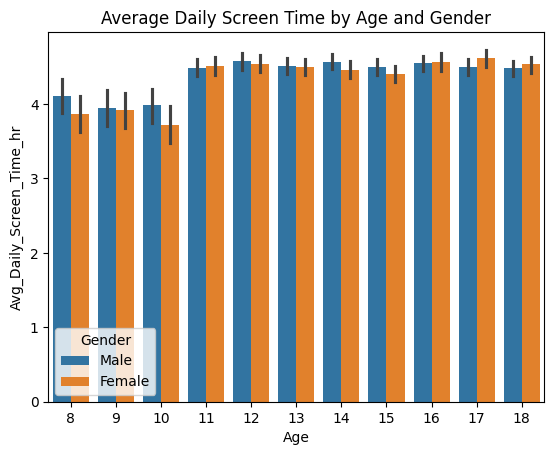

In [217]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load sample data
df = pd.read_csv("Indian_Kids_Screen_Time.csv")

# Plot average daily usage by age group and gender
sns.barplot(data=df, x='Age', y='Avg_Daily_Screen_Time_hr', hue='Gender')
plt.title("Average Daily Screen Time by Age and Gender")
plt.show()

In [218]:
avg = df['Avg_Daily_Screen_Time_hr'].mean()
print(avg)

4.3528366968698515


In [219]:
df = pd.read_csv("Indian_Kids_Screen_Time.csv")
df[df['Avg_Daily_Screen_Time_hr'] > avg].value_counts()

Age  Gender  Avg_Daily_Screen_Time_hr  Primary_Device  Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  Health_Impacts            Urban_or_Rural
18   Male    5.98                      Smartphone      True                        0.49                               Poor Sleep, Eye Strain    Urban             2
16   Female  4.42                      Laptop          True                        0.35                               Poor Sleep, Anxiety       Urban             2
9    Female  4.44                      TV              True                        0.50                               Poor Sleep                Urban             2
8    Female  4.84                      Smartphone      True                        0.46                               Poor Sleep                Rural             2
15   Male    4.36                      Tablet          True                        0.39                               Poor Sleep, Anxiety       Urban             1
                                                                                                                                                                 ..
12   Female  4.84                      Laptop          True                        0.30                               Poor Sleep                Urban             1
             4.83                      TV              True                        0.42                               Eye Strain                Urban             1
                                       Smartphone      True                        0.46                               Poor Sleep, Obesity Risk  Urban             1
                                                                                   0.37                               Poor Sleep                Rural             1
             4.93                      Smartphone      True                        0.46                               Poor Sleep                Urban             1
Name: count, Length: 4103, dtype: int64

In [220]:
df[df['Exceeded_Recommended_Limit'] == False].sort_values(by='Avg_Daily_Screen_Time_hr' , ascending=False)

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
9029,12,Male,3.0,Smartphone,False,0.49,NaN,Urban
4451,14,Female,3.0,Tablet,False,0.44,NaN,Urban
2840,14,Female,3.0,Smartphone,False,0.36,NaN,Urban
987,12,Female,3.0,Smartphone,False,0.36,NaN,Rural
8793,18,Female,3.0,Laptop,False,0.49,NaN,Rural
...,...,...,...,...,...,...,...,...
4703,10,Female,0.0,TV,False,0.47,NaN,Urban
4693,8,Female,0.0,Smartphone,False,0.50,NaN,Rural
4690,10,Male,0.0,Tablet,False,0.58,NaN,Rural
4881,9,Male,0.0,TV,False,0.47,NaN,Urban


In [221]:
df.groupby('Exceeded_Recommended_Limit', as_index=False)['Avg_Daily_Screen_Time_hr'].mean()


,Exceeded_Recommended_Limit,Avg_Daily_Screen_Time_hr
0,False,1.581751
1,True,4.823865


In [222]:
df[df['Avg_Daily_Screen_Time_hr'] > avg].value_counts()

Age  Gender  Avg_Daily_Screen_Time_hr  Primary_Device  Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  Health_Impacts            Urban_or_Rural
18   Male    5.98                      Smartphone      True                        0.49                               Poor Sleep, Eye Strain    Urban             2
16   Female  4.42                      Laptop          True                        0.35                               Poor Sleep, Anxiety       Urban             2
9    Female  4.44                      TV              True                        0.50                               Poor Sleep                Urban             2
8    Female  4.84                      Smartphone      True                        0.46                               Poor Sleep                Rural             2
15   Male    4.36                      Tablet          True                        0.39                               Poor Sleep, Anxiety       Urban             1
                                                                                                                                                                 ..
12   Female  4.84                      Laptop          True                        0.30                               Poor Sleep                Urban             1
             4.83                      TV              True                        0.42                               Eye Strain                Urban             1
                                       Smartphone      True                        0.46                               Poor Sleep, Obesity Risk  Urban             1
                                                                                   0.37                               Poor Sleep                Rural             1
             4.93                      Smartphone      True                        0.46                               Poor Sleep                Urban             1
Name: count, Length: 4103, dtype: int64

In [223]:
df[df['Exceeded_Recommended_Limit'] == True].sort_values(by='Avg_Daily_Screen_Time_hr' , ascending=True)

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
8152,8,Female,2.01,Smartphone,True,0.60,NaN,Urban
8532,9,Male,2.01,TV,True,0.54,NaN,Urban
356,8,Male,2.02,Smartphone,True,0.57,NaN,Urban
3236,9,Female,2.02,Smartphone,True,0.40,NaN,Urban
696,8,Female,2.03,TV,True,0.47,NaN,Rural
...,...,...,...,...,...,...,...,...
1321,10,Female,12.09,Tablet,True,0.45,Poor Sleep,Urban
1870,10,Male,12.40,Smartphone,True,0.52,NaN,Urban
1769,9,Male,12.80,TV,True,0.56,"Eye Strain, Anxiety",Rural
934,10,Female,13.01,Smartphone,True,0.57,"Poor Sleep, Anxiety",Urban


In [224]:
df['Avg_Daily_Screen_Time_hr'].value_counts()

,count
Avg_Daily_Screen_Time_hr,
0.00,226
4.93,41
4.32,39
4.03,39
4.96,39
...,...
7.84,1
8.54,1
10.18,1


In [225]:
age_group_avg = df.groupby('Age')['Avg_Daily_Screen_Time_hr'].mean()
age_group_avg

,Avg_Daily_Screen_Time_hr
Age,
8,3.988925
9,3.932181
10,3.851425
11,4.497263
12,4.554348
13,4.500967
14,4.514821
15,4.441725
16,4.551781


In [226]:
device_avg = df.groupby('Primary_Device')['Avg_Daily_Screen_Time_hr'].mean()
device_avg

,Avg_Daily_Screen_Time_hr
Primary_Device,
Laptop,4.459086
Smartphone,4.388925
TV,4.287752
Tablet,4.226005


In [227]:
above_avg_devices = device_avg[device_avg > avg]
above_avg_devices

,Avg_Daily_Screen_Time_hr
Primary_Device,
Laptop,4.459086
Smartphone,4.388925


In [228]:
gender_avg = df.groupby('Gender')['Avg_Daily_Screen_Time_hr'].mean()
print(gender_avg)

Gender
Female    4.327021
Male      4.377754
Name: Avg_Daily_Screen_Time_hr, dtype: float64


In [229]:
age_group_avg=df.groupby('Age')['Avg_Daily_Screen_Time_hr'].mean()
print(age_group_avg)

Age
8     3.988925
9     3.932181
10    3.851425
11    4.497263
12    4.554348
13    4.500967
14    4.514821
15    4.441725
16    4.551781
17    4.555397
18    4.503976
Name: Avg_Daily_Screen_Time_hr, dtype: float64


In [230]:
device_gender_avg=df.groupby(['Primary_Device','Gender'])['Avg_Daily_Screen_Time_hr'].mean()
print(device_gender_avg)

Primary_Device  Gender
Laptop          Female    4.481066
                Male      4.435549
Smartphone      Female    4.332350
                Male      4.442463
TV              Female    4.283465
                Male      4.291868
Tablet          Female    4.203407
                Male      4.247035
Name: Avg_Daily_Screen_Time_hr, dtype: float64


In [231]:
top_device=df.groupby('Primary_Device')['Avg_Daily_Screen_Time_hr'].mean().idxmax()
print("Device with highest screen time:",top_device)

Device with highest screen time: Laptop


In [232]:
avg_screen_time = df['Avg_Daily_Screen_Time_hr'].mean()
above_avg = df[df['Avg_Daily_Screen_Time_hr'] > avg_screen_time]
below_avg = df[df['Avg_Daily_Screen_Time_hr'] <= avg_screen_time]

print("Above average users:", len(above_avg))
print("Below average users:", len(below_avg))

Above average users: 5048
Below average users: 4664


In [233]:
location_avg = df.groupby('Urban_or_Rural')['Avg_Daily_Screen_Time_hr'].mean()
print(location_avg)

Urban_or_Rural
Rural    4.373702
Urban    4.344123
Name: Avg_Daily_Screen_Time_hr, dtype: float64


In [234]:
limit_avg = df.groupby('Exceeded_Recommended_Limit')['Avg_Daily_Screen_Time_hr'].mean()
print(limit_avg)

Exceeded_Recommended_Limit
False    1.581751
True     4.823865
Name: Avg_Daily_Screen_Time_hr, dtype: float64


In [235]:
gender_limit = df.groupby(['Gender', 'Exceeded_Recommended_Limit']).size().unstack()
print(gender_limit)

Exceeded_Recommended_Limit  False  True 
Gender                                  
Female                        745   4025
Male                          666   4276


In [236]:
correlation = df['Avg_Daily_Screen_Time_hr'].corr(df['Educational_to_Recreational_Ratio'])
print("Correlation:", correlation)

Correlation: -0.08755222315597143


In [237]:
device_ratio = df.groupby('Primary_Device')['Educational_to_Recreational_Ratio'].mean()
print(device_ratio)

Primary_Device
Laptop        0.399002
Smartphone    0.422077
TV            0.443703
Tablet        0.446005
Name: Educational_to_Recreational_Ratio, dtype: float64


In [238]:
limit_per_device = (
    df.groupby('Primary_Device')['Exceeded_Recommended_Limit']
    .value_counts(normalize=True)
    .unstack()
    * 100
)
print(limit_per_device)

Exceeded_Recommended_Limit      False      True 
Primary_Device                                  
Laptop                      11.025820  88.974180
Smartphone                  13.550788  86.449212
TV                          16.164053  83.835947
Tablet                      18.954248  81.045752


In [239]:
health_by_gender = df.groupby('Gender')['Health_Impacts'].value_counts().unstack().fillna(0)
print(health_by_gender)

Health_Impacts  Anxiety  Anxiety, Obesity Risk  Eye Strain  \
Gender                                                       
Female              186                     35         324   
Male                199                     34         320   

Health_Impacts  Eye Strain, Anxiety  Eye Strain, Anxiety, Obesity Risk  \
Gender                                                                   
Female                           68                                 16   
Male                             67                                 19   

Health_Impacts  Eye Strain, Obesity Risk  Obesity Risk  Poor Sleep  \
Gender                                                               
Female                                53           103        1117   
Male                                  53           149        1151   

Health_Impacts  Poor Sleep, Anxiety  Poor Sleep, Anxiety, Obesity Risk  \
Gender                                                                   
Female                   

In [240]:
health_time = df.groupby('Health_Impacts')['Avg_Daily_Screen_Time_hr'].mean().sort_values(ascending=False)
print(health_time)

Health_Impacts
Eye Strain, Anxiety                              5.081185
Poor Sleep, Anxiety, Obesity Risk                5.060641
Poor Sleep, Obesity Risk                         5.015376
Eye Strain, Anxiety, Obesity Risk                4.993429
Poor Sleep                                       4.955445
Eye Strain, Obesity Risk                         4.949811
Poor Sleep, Eye Strain, Anxiety                  4.911667
Obesity Risk                                     4.911151
Poor Sleep, Anxiety                              4.906283
Anxiety                                          4.903403
Poor Sleep, Eye Strain                           4.883207
Poor Sleep, Eye Strain, Obesity Risk             4.818617
Eye Strain                                       4.809301
Anxiety, Obesity Risk                            4.648841
Poor Sleep, Eye Strain, Anxiety, Obesity Risk    4.548378
Name: Avg_Daily_Screen_Time_hr, dtype: float64


In [241]:
limit_by_location = (
    df.groupby('Urban_or_Rural')['Exceeded_Recommended_Limit']
    .value_counts(normalize=True)
    .unstack()
    * 100
)
print(limit_by_location)

Exceeded_Recommended_Limit      False      True 
Urban_or_Rural                                  
Rural                       14.645229  85.354771
Urban                       14.479638  85.520362


In [242]:
device_health = df.groupby(['Primary_Device', 'Health_Impacts'])['Avg_Daily_Screen_Time_hr'].mean()
print(device_health)

Primary_Device  Health_Impacts                               
Laptop          Anxiety                                          4.687419
                Anxiety, Obesity Risk                            4.487273
                Eye Strain                                       4.692871
                Eye Strain, Anxiety                              5.024286
                Eye Strain, Anxiety, Obesity Risk                4.722857
                Eye Strain, Obesity Risk                         4.783125
                Obesity Risk                                     5.031892
                Poor Sleep                                       4.711405
                Poor Sleep, Anxiety                              4.614074
                Poor Sleep, Anxiety, Obesity Risk                5.156000
                Poor Sleep, Eye Strain                           4.683176
                Poor Sleep, Eye Strain, Anxiety                  4.782308
                Poor Sleep, Eye Strain, Anxiety, O

In [243]:
import pandas as pd
df = pd.read_csv("/content/Indian_Kids_Screen_Time.csv")
df.iloc[2:8]


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban
5,14,Female,4.88,Smartphone,True,0.44,Poor Sleep,Urban
6,17,Male,2.97,TV,False,0.48,NaN,Rural
7,10,Male,2.74,TV,True,0.54,NaN,Urban


<Axes: xlabel='Educational_to_Recreational_Ratio', ylabel='Avg_Daily_Screen_Time_hr'>

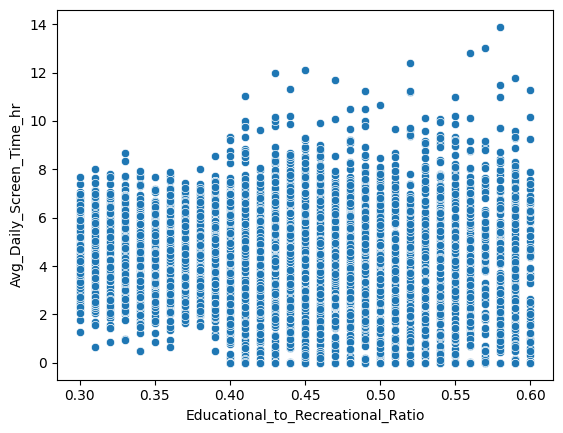

In [244]:
sns.scatterplot(x="Educational_to_Recreational_Ratio", y="Avg_Daily_Screen_Time_hr", data=df)

In [245]:
health_impacts_summary = df['Health_Impacts'].value_counts()
display(health_impacts_summary)

,count
Health_Impacts,
Poor Sleep,2268
"Poor Sleep, Eye Strain",979
Eye Strain,644
"Poor Sleep, Anxiety",608
"Poor Sleep, Obesity Risk",452
Anxiety,385
"Poor Sleep, Eye Strain, Anxiety",258
Obesity Risk,252
"Poor Sleep, Eye Strain, Obesity Risk",188


In [246]:

data = {
    'Age': [15, 25, 35, 45, 55],
    'Gender': ['Male', 'Female', 'Male', 'Female', 'Male'],
    'Avg_Daily_Screen_Time_hr': [5, 6, 4, 3, 2],
    'Primary_Device': ['Phone', 'Laptop', 'Tablet', 'Phone', 'Laptop'],
    'Exceeded_Recommended_Limit': ['Yes', 'Yes', 'No', 'No', 'No'],
    'Educational_to_Recreational_Ratio': [0.4, 0.5, 0.8, 0.9, 1.0],
    'Health_Impacts': ['Eye strain', 'Poor sleep', 'None', 'None', 'None'],
    'Urban_or_Rural': ['Urban', 'Urban', 'Rural', 'Urban', 'Rural']
}

df = pd.DataFrame(data)


def get_recommendation(age, gender, avg_screen_time, primary_device, urban_or_rural):
    recommendations = []

    # 1. General health-based recommendation
    if avg_screen_time > 4:
        recommendations.append("⚠️ Your average screen time is higher than recommended (4 hours). Try reducing non-essential usage.")
    else:
        recommendations.append("✅ Your screen time is within a healthy range. Keep it up!")

    # 2. Educational vs recreational ratio insights
    avg_ratio = df['Educational_to_Recreational_Ratio'].mean()
    if avg_screen_time > 4 and avg_ratio < 0.6:
        recommendations.append("📘 Consider dedicating more screen time to educational or productive activities.")

    # 3. Age-specific recommendation
    if age < 18:
        recommendations.append("👦 Teen users should limit screen time to under 3 hours per day for better sleep and focus.")
    elif 18 <= age <= 35:
        recommendations.append("👩‍💻 Maintain a balance between work and leisure screen time. Avoid using devices right before sleep.")
    else:
        recommendations.append("🧑‍🦳 Take regular breaks every 30 minutes to avoid eye strain.")

    # 4. Gender-based insight (example trend)
    gender_avg = df[df['Gender'] == gender]['Avg_Daily_Screen_Time_hr'].mean()
    recommendations.append(f"📊 Average screen time for {gender}s in your dataset is {gender_avg:.1f} hours per day.")

    # 5. Device-based tip
    if primary_device.lower() == "phone":
        recommendations.append("📱 Try enabling app timers or grayscale mode to reduce excessive phone usage.")
    elif primary_device.lower() == "laptop":
        recommendations.append("💻 Use blue light filters and take short breaks every hour.")
    else:
        recommendations.append("🖥️ Adjust brightness and posture to avoid neck and eye strain.")

    # 6. Urban vs Rural lifestyle insights
    if urban_or_rural.lower() == "urban":
        recommendations.append("🏙️ Urban users often experience digital overload — consider tech-free time outdoors.")
    else:
        recommendations.append("🌄 Rural users often have balanced screen habits — keep maintaining that lifestyle!")

    return recommendations



try:
    age = int(input("Enter your age: "))
    gender = input("Enter your gender (Male/Female): ").capitalize()
    avg_screen_time = float(input("Enter your average daily screen time (in hours): "))
    primary_device = input("Enter your primary device (Phone/Laptop/Tablet): ")
    urban_or_rural = input("Do you live in an Urban or Rural area?: ")

    print("\n=== Personalized Recommendations ===")
    user_recs = get_recommendation(age, gender, avg_screen_time, primary_device, urban_or_rural)
    for rec in user_recs:
        print("-", rec)

except Exception as e:
    print("⚠️ Error:", e)


Enter your age: 12
Enter your gender (Male/Female): M
Enter your average daily screen time (in hours): 9
Enter your primary device (Phone/Laptop/Tablet): phone
Do you live in an Urban or Rural area?: urban

=== Personalized Recommendations ===
- ⚠️ Your average screen time is higher than recommended (4 hours). Try reducing non-essential usage.
- 👦 Teen users should limit screen time to under 3 hours per day for better sleep and focus.
- 📊 Average screen time for Ms in your dataset is nan hours per day.
- 📱 Try enabling app timers or grayscale mode to reduce excessive phone usage.
- 🏙️ Urban users often experience digital overload — consider tech-free time outdoors.


In [247]:
correlation_matrix = df.corr(numeric_only=True)
display(correlation_matrix)

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
Age,1.000000,-0.900000,0.977356
Avg_Daily_Screen_Time_hr,-0.900000,1.000000,-0.916271
Educational_to_Recreational_Ratio,0.977356,-0.916271,1.000000


In [248]:
df = pd.read_csv("/content/Indian_Kids_Screen_Time.csv")
exceeded_counts = df['Exceeded_Recommended_Limit'].value_counts()
display(exceeded_counts)

,count
Exceeded_Recommended_Limit,
True,8301
False,1411


In [249]:
average_metrics_by_gender = df.groupby('Gender')[['Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio']].mean()
display(average_metrics_by_gender)

average_metrics_by_device = df.groupby('Primary_Device')[['Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio']].mean()
display(average_metrics_by_device)

average_metrics_by_location = df.groupby('Urban_or_Rural')[['Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio']].mean()
display(average_metrics_by_location)

average_metrics_by_age = df.groupby('Age')[['Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio']].mean()
display(average_metrics_by_age)

average_metrics_by_health_impacts = df.groupby('Health_Impacts')[['Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio']].mean()
display(average_metrics_by_health_impacts)


,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
Gender,,
Female,4.327021,0.426694
Male,4.377754,0.427740


,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
Primary_Device,,
Laptop,4.459086,0.399002
Smartphone,4.388925,0.422077
TV,4.287752,0.443703
Tablet,4.226005,0.446005


,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
Urban_or_Rural,,
Rural,4.373702,0.427864
Urban,4.344123,0.426960


,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
Age,,
8,3.988925,0.498070
9,3.932181,0.502746
10,3.851425,0.500924
11,4.497263,0.402610
12,4.554348,0.399654
13,4.500967,0.400440
14,4.514821,0.398862
15,4.441725,0.398843
16,4.551781,0.399452


,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
Health_Impacts,,
Anxiety,4.903403,0.419974
"Anxiety, Obesity Risk",4.648841,0.409855
Eye Strain,4.809301,0.420062
"Eye Strain, Anxiety",5.081185,0.420444
"Eye Strain, Anxiety, Obesity Risk",4.993429,0.425714
"Eye Strain, Obesity Risk",4.949811,0.431132
Obesity Risk,4.911151,0.420635
Poor Sleep,4.955445,0.421424
"Poor Sleep, Anxiety",4.906283,0.418092


In [250]:
print("Recommendation logic and types of recommendations defined.")


Recommendation logic and types of recommendations defined.


In [251]:
def get_screen_time_recommendations(age, gender, avg_daily_screen_time_hr, educational_to_recreational_ratio, primary_device, health_impacts):
    recommendations = []

    average_screen_time = df['Avg_Daily_Screen_Time_hr'].mean()

    if avg_daily_screen_time_hr > average_screen_time:
        percentage_higher = ((avg_daily_screen_time_hr - average_screen_time) / average_screen_time) * 100
        recommendations.append(f"Warning: Your screen time is {percentage_higher:.1f}% higher than the average ({average_screen_time:.1f} hrs) and may exceed recommended limits.")
        recommendations.append("Consider reducing your overall screen time.")
    elif avg_daily_screen_time_hr < average_screen_time:
        percentage_lower = ((average_screen_time - avg_daily_screen_time_hr) / average_screen_time) * 100
        recommendations.append(f"Your screen time is {percentage_lower:.1f}% lower than the average ({average_screen_time:.1f} hrs). Keep up the good habits!")
    else:
        recommendations.append("Your screen time is around the average.")

    average_edu_recre_ratio = df['Educational_to_Recreational_Ratio'].mean()
    if educational_to_recreational_ratio < average_edu_recre_ratio * 0.9:
        recommendations.append("Try to increase the proportion of educational content in your screen time.")

    if health_impacts != 'None':
        recommendations.append("Be mindful of the reported health impacts and consider seeking professional advice if needed.")
        if 'Poor Sleep' in health_impacts:
            recommendations.append("Avoid screens for at least an hour before bedtime to improve sleep quality.")
        if 'Eye Strain' in health_impacts:
            recommendations.append("Remember to take regular breaks during screen time to rest your eyes and body.")
        if 'Obesity Risk' in health_impacts:
            recommendations.append("Explore alternative activities like reading, sports, or spending time outdoors.")

    device_health_impacts = df[(df['Primary_Device'] == primary_device) & (df['Health_Impacts'] != 'None')]['Health_Impacts'].value_counts()
    if not device_health_impacts.empty:
        most_common_impact = device_health_impacts.index[0]
        recommendations.append(f"For users of {primary_device}, the most commonly observed health impact is '{most_common_impact}'.")

    average_screen_time_for_device = df[df['Primary_Device'] == primary_device]['Avg_Daily_Screen_Time_hr'].mean()
    recommendations.append(f"The average daily screen time for users of {primary_device} is approximately {average_screen_time_for_device:.1f} hours.")

    average_screen_time_by_age_gender = df[(df['Age'] == age) & (df['Gender'] == gender)]['Avg_Daily_Screen_Time_hr'].mean()
    if not pd.isna(average_screen_time_by_age_gender):
        recommendations.append(f"The average screen time for kids aged {age} who are {gender} is approximately {average_screen_time_by_age_gender:.1f} hours.")


    if age <= 10 and avg_daily_screen_time_hr > 2:
         recommendations.append("For younger children, focus on educational and interactive content with parental guidance.")
    elif age > 10 and avg_daily_screen_time_hr > 4:
        recommendations.append("Consider setting screen time limits and encouraging a balance with other activities.")

    if primary_device == 'Smartphone':
        recommendations.append("Be mindful of your smartphone usage duration and consider using blue light filters.")


    return recommendations


In [255]:
import pandas as pd
import numpy as np

In [263]:
df = pd.read_csv("Indian_Kids_Screen_Time.csv")

In [267]:
import pandas as pd


df = pd.read_csv("Indian_Kids_Screen_Time.csv")


limit = 2

above_limit = df[df['Avg_Daily_Screen_Time_hr'] > limit]
within_limit = df[df['Avg_Daily_Screen_Time_hr'] <= limit]

min_screen_time_above_limit = above_limit['Avg_Daily_Screen_Time_hr'].min()
max_screen_time_within_limit = within_limit['Avg_Daily_Screen_Time_hr'].max()

print(f"Minimum average daily screen time for those who exceeded the limit: {min_screen_time_above_limit:.2f} hrs")
print(f"Maximum average daily screen time for those within the limit: {max_screen_time_within_limit:.2f} hrs")

Minimum average daily screen time for those who exceeded the limit: 2.01 hrs
Maximum average daily screen time for those within the limit: 2.00 hrs


In [268]:
average_ratio_above_limit = above_limit['Educational_to_Recreational_Ratio'].mean()
average_ratio_within_limit = within_limit['Educational_to_Recreational_Ratio'].mean()

print(f"Average Educational to Recreational Ratio for those who exceeded the limit: {average_ratio_above_limit:.2f}")
print(f"Average Educational to Recreational Ratio for those within the limit: {average_ratio_within_limit:.2f}")

Average Educational to Recreational Ratio for those who exceeded the limit: 0.42
Average Educational to Recreational Ratio for those within the limit: 0.48


In [269]:
health_impacts_above_limit_counts = above_limit[above_limit['Health_Impacts'] != 'None']['Health_Impacts'].value_counts()
health_impacts_within_limit_counts = within_limit[within_limit['Health_Impacts'] != 'None']['Health_Impacts'].value_counts()

print("Health Impacts for those who exceeded the recommended limit (excluding 'None'):")
display(health_impacts_above_limit_counts)

print("\nHealth Impacts for those within the recommended limit (excluding 'None'):")
display(health_impacts_within_limit_counts)


Health Impacts for those who exceeded the recommended limit (excluding 'None'):


,count
Health_Impacts,
Poor Sleep,2268
"Poor Sleep, Eye Strain",979
Eye Strain,644
"Poor Sleep, Anxiety",608
"Poor Sleep, Obesity Risk",452
Anxiety,385
"Poor Sleep, Eye Strain, Anxiety",258
Obesity Risk,252
"Poor Sleep, Eye Strain, Obesity Risk",188



Health Impacts for those within the recommended limit (excluding 'None'):


,count
Health_Impacts,


In [270]:
print("Demographics for those who exceeded the recommended limit:")
display(above_limit['Age'].value_counts().sort_index())
display(above_limit['Gender'].value_counts())
display(above_limit['Primary_Device'].value_counts())
display(above_limit['Urban_or_Rural'].value_counts())

print("\nDemographics for those within the recommended limit:")
display(within_limit['Age'].value_counts().sort_index())
display(within_limit['Gender'].value_counts())
display(within_limit['Primary_Device'].value_counts())
display(within_limit['Urban_or_Rural'].value_counts())


Demographics for those who exceeded the recommended limit:


,count
Age,
8,684
9,648
10,639
11,846
12,852
13,891
14,879
15,852
16,860


,count
Gender,
Male,4547
Female,4333


,count
Primary_Device,
Smartphone,4227
TV,2200
Laptop,1395
Tablet,1058


,count
Urban_or_Rural,
Urban,6272
Rural,2608



Demographics for those within the recommended limit:


,count
Age,
8,228
9,237
10,238
11,20
12,15
13,19
14,17
15,12
16,16


,count
Gender,
Female,437
Male,395


,count
Primary_Device,
Smartphone,341
TV,287
Tablet,166
Laptop,38


,count
Urban_or_Rural,
Urban,579
Rural,253
